In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import boto3
import pickle
import warnings
# Suppress PerformanceWarning
warnings.filterwarnings('ignore')
from passwords import *

try:
    import catboost
except:
    ! pip install catboost

### Functions

In [2]:
# # download from s3
# def download_from_s3(aws_access_key_id, aws_secret_access_key, str_local_path, str_bucket_path, str_project):
#     # init client
#     cls_client = boto3.client(
#         's3',
#         aws_access_key_id=aws_access_key_id,
#         aws_secret_access_key=aws_secret_access_key,
#     )
#     # download file
#     cls_client.download_file(
#         str_project, 
#         str_bucket_path, 
#         str_local_path,
#     )

In [3]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # init client
    cls_client = boto3.client(
        's3',
    )
    # download file
    cls_client.download_file(
        str_project, 
        str_bucket_path, 
        str_local_path,
    )

### Constants

In [4]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

# output
str_dirname_output = './output'

# ids
str_id = 'bigAccountId'
str_datecol = 'applicationdate__app'
str_target = 'target'

# list ids
list_cols_id = [
    str_id,
    str_datecol,
    str_target,
    'amtfinanced__app',
    'bookvalue__app',
    'intopenbktype__app',
    'bitdebtor__app',
    'fico__app',
]

str_variant_pd = 'noPTImodel10' # optimized for logloss
#str_variant_pd = 'noPTI_noDown_model1' # optimized for logloss

str_variant_lgd = 'noPTImodel10'
#str_variant_lgd = 'noPTI_noDown_model1'

int_n_quantiles = 10

Project: 20231010-gen-xii


### Output

In [5]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### PD model

In [6]:
str_filename = 'final_model.pkl'
str_bucket_path = f'02_pricing_pd/02_model/{str_variant_pd}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
#     aws_access_key_id=AWS_ACCESS_KEY_ID, 
#     aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    str_local_path=str_local_path,
    str_bucket_path=str_bucket_path,
    str_project=str_project,
)
cls_model_pd = pickle.load(open(str_local_path, 'rb'))['model_inference']
list_cols_model_pd = list(cls_model_pd.feature_names_)
print(f'There are {len(list_cols_model_pd)} columns in the PD model')
os.remove(str_local_path)

There are 122 columns in the PD model


### LGD model

In [7]:
str_filename = 'final_model.pkl'
str_bucket_path = f'03_pricing_lgd/02_model/{str_variant_lgd}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
#     aws_access_key_id=AWS_ACCESS_KEY_ID, 
#     aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    str_local_path=str_local_path,
    str_bucket_path=str_bucket_path,
    str_project=str_project,
)
cls_model_lgd = pickle.load(open(str_local_path, 'rb'))['model_inference']
list_cols_model_lgd = list(cls_model_lgd.feature_names_)
print(f'There are {len(list_cols_model_lgd)} columns in the LGD model')
os.remove(str_local_path)

There are 76 columns in the LGD model


### Combine lists

In [8]:
list_cols_models = list_cols_model_pd + list_cols_model_lgd
list_cols_models = list(dict.fromkeys(list_cols_models))
print(f'There are {len(list_cols_models)} features total')

There are 177 features total


### Add IDs

In [9]:
list_cols_import = list_cols_id + list_cols_models
list_cols_import = list(dict.fromkeys(list_cols_import))
print(f'There are {len(list_cols_import)} features to import')

There are 183 features to import


### Rm engineered cols

In [10]:
list_cols_import = [col for col in list_cols_import if 'ENG-' not in col]
print(f'There are {len(list_cols_import)} features to import')

There are 181 features to import


### Forced features

In [11]:
list_cols_force = [
    'vehicleyear__app',
    'dealerstampcreation__app',
]
list_cols_import = list_cols_import + list_cols_force
list_cols_import = list(dict.fromkeys(list_cols_import))
print(f'There are {len(list_cols_import)} features to import')

There are 183 features to import


### Import PD test and holdout data

In [12]:
list_str_df = [
    'test',
    'holdout',
]
list_df = []
for str_df in list_str_df:
    str_filename = f'df_{str_df}_raw.gzip'
    str_bucket_path = f'04_pd/01_data_prep/03_train_valid_test_split/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
#         aws_access_key_id=AWS_ACCESS_KEY_ID, 
#         aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
        str_local_path=str_local_path,
        str_bucket_path=str_bucket_path,
        str_project='20240327-genxii-v2',
    )
    df = pd.read_parquet(str_local_path, columns=list_cols_import)
    os.remove(str_local_path)
    df['data_set'] = str_df
    list_df.append(df)
df = pd.concat(list_df)
df

,bigAccountId,applicationdate__app,target,amtfinanced__app,bookvalue__app,intopenbktype__app,bitdebtor__app,fico__app,fltgrossmonthly__income_sum,bankruptcystatus__ln,...,fi36s__tu,rev201__tu,bankruptcychapter__ln,g216s__tu,linka005__tu,fr02s__tu,fr21s__tu,vehicleyear__app,dealerstampcreation__app,data_set
12946,5902015,2022-01-20 11:06:14.877,0,26170.00,17550.0,NaN,1,620.0,4641.00,0.0,...,13.0,3.33,0.0,0.0,0.0,-1.0,-1.0,2022,2006-04-02 14:10:47.000,test
12590,5902037,2022-01-20 11:19:40.037,1,10270.81,6469.0,NaN,1,555.0,2968.18,0.0,...,999.0,4.36,0.0,2.0,0.0,-1.0,-1.0,2015,2003-07-08 14:32:29.097,test
13218,5902110,2022-01-20 11:59:23.367,0,24482.77,16760.0,NaN,1,517.0,3958.93,0.0,...,999.0,-2.00,0.0,1.0,0.0,-1.0,-1.0,2017,2017-03-20 13:48:00.593,test
14629,5902134,2022-01-20 12:10:08.247,1,17966.93,14425.0,NaN,1,483.0,3156.40,0.0,...,1.0,-2.00,0.0,0.0,0.0,-1.0,-1.0,2017,2013-05-02 16:09:43.367,test
12750,5902141,2022-01-20 12:12:41.577,1,27675.29,19059.0,NaN,1,NaN,2899.60,0.0,...,26.0,-1.00,0.0,-1.0,0.0,-1.0,-1.0,2021,2010-02-17 13:43:39.010,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43795,6516344,2022-12-28 14:28:25.923,0,20733.48,16637.0,7.0,1,528.0,3321.06,-1.0,...,999.0,-2.00,1.0,4.0,0.0,0.0,25.0,2017,2009-06-19 13:39:58.367,holdout
43720,6516517,2022-12-28 15:11:41.943,0,19614.88,13535.0,NaN,1,562.0,5072.00,0.0,...,-1.0,-2.00,0.0,-1.0,0.0,-1.0,-1.0,2013,2015-04-23 15:33:39.653,holdout
43819,6517682,2022-12-29 11:15:23.287,1,27875.63,20600.0,NaN,0,497.0,1950.00,2.0,...,1.0,-2.00,2.0,3.0,0.0,-1.0,-1.0,2017,2008-02-04 11:39:20.800,holdout
43820,6517682,2022-12-29 11:15:23.287,1,27875.63,20600.0,NaN,1,502.0,4819.29,2.0,...,1.0,-2.00,2.0,2.0,0.0,-1.0,-1.0,2017,2008-02-04 11:39:20.800,holdout


### Get the loss file

In [13]:
list_cols = [
    'bigAccountId',
    'fltNetChgOff',
    'months_on_books',
]
str_filename = 'df_loss.gzip'
str_bucket_path = f'02_target_creation/02_regression/{str_filename}'
str_local_path = f'./{str_filename}'
download_from_s3(
#     aws_access_key_id=AWS_ACCESS_KEY_ID, 
#     aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    str_local_path=str_local_path,
    str_bucket_path=str_bucket_path,
    str_project='20240327-genxii-v2',
)
df_tmp = pd.read_parquet(str_local_path, columns=list_cols)
os.remove(str_local_path)
df_tmp = df_tmp[df_tmp['months_on_books'] == 24].copy()
df_tmp

,bigAccountId,fltNetChgOff,months_on_books
index,,,
510,3617635,4406.98,24
1012,3583875,6709.63,24
1082,3599428,19541.18,24
1783,3593078,11362.39,24
4295,3618035,14586.30,24
...,...,...,...
139062,6475788,421.35,24
139063,6486438,402.59,24
139065,6497045,34280.97,24


### Join

In [14]:
df = pd.merge(
    left=df,
    right=df_tmp,
    on='bigAccountId',
    how='left',
)
# fillna
df['fltNetChgOff'] = df['fltNetChgOff'].fillna(0)
# clip
df['fltNetChgOff'] = df['fltNetChgOff'].clip(lower=0)
# create prop_loss
df['prop_loss'] = df['fltNetChgOff'] / df['amtfinanced__app']
# show
df

,bigAccountId,applicationdate__app,target,amtfinanced__app,bookvalue__app,intopenbktype__app,bitdebtor__app,fico__app,fltgrossmonthly__income_sum,bankruptcystatus__ln,...,g216s__tu,linka005__tu,fr02s__tu,fr21s__tu,vehicleyear__app,dealerstampcreation__app,data_set,fltNetChgOff,months_on_books,prop_loss
0,5902015,2022-01-20 11:06:14.877,0,26170.00,17550.0,NaN,1,620.0,4641.00,0.0,...,0.0,0.0,-1.0,-1.0,2022,2006-04-02 14:10:47.000,test,0.00,NaN,0.000000
1,5902037,2022-01-20 11:19:40.037,1,10270.81,6469.0,NaN,1,555.0,2968.18,0.0,...,2.0,0.0,-1.0,-1.0,2015,2003-07-08 14:32:29.097,test,5498.51,24.0,0.535353
2,5902110,2022-01-20 11:59:23.367,0,24482.77,16760.0,NaN,1,517.0,3958.93,0.0,...,1.0,0.0,-1.0,-1.0,2017,2017-03-20 13:48:00.593,test,0.00,NaN,0.000000
3,5902134,2022-01-20 12:10:08.247,1,17966.93,14425.0,NaN,1,483.0,3156.40,0.0,...,0.0,0.0,-1.0,-1.0,2017,2013-05-02 16:09:43.367,test,10278.02,24.0,0.572052
4,5902141,2022-01-20 12:12:41.577,1,27675.29,19059.0,NaN,1,NaN,2899.60,0.0,...,-1.0,0.0,-1.0,-1.0,2021,2010-02-17 13:43:39.010,test,885.48,24.0,0.031995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30915,6516344,2022-12-28 14:28:25.923,0,20733.48,16637.0,7.0,1,528.0,3321.06,-1.0,...,4.0,0.0,0.0,25.0,2017,2009-06-19 13:39:58.367,holdout,0.00,NaN,0.000000
30916,6516517,2022-12-28 15:11:41.943,0,19614.88,13535.0,NaN,1,562.0,5072.00,0.0,...,-1.0,0.0,-1.0,-1.0,2013,2015-04-23 15:33:39.653,holdout,0.00,NaN,0.000000
30917,6517682,2022-12-29 11:15:23.287,1,27875.63,20600.0,NaN,0,497.0,1950.00,2.0,...,3.0,0.0,-1.0,-1.0,2017,2008-02-04 11:39:20.800,holdout,17851.63,24.0,0.640403
30918,6517682,2022-12-29 11:15:23.287,1,27875.63,20600.0,NaN,1,502.0,4819.29,2.0,...,2.0,0.0,-1.0,-1.0,2017,2008-02-04 11:39:20.800,holdout,17851.63,24.0,0.640403


### Preprocess

In [15]:
# preprocess
list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in tqdm(list_str_filename):
    # download
    str_bucket_path = f'01_ad/02_model/noPTImodel10/00_preprocessing/01_create_preprocessor/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
#         aws_access_key_id=AWS_ACCESS_KEY_ID, 
#         aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
        str_local_path=str_local_path, 
        str_bucket_path=str_bucket_path, 
        str_project='20231010-gen-xii',
    )

# import
cls_model_preprocessing = pickle.load(open(str_local_path, 'rb'))
os.remove(str_local_path)

# save lists of targets so they dont get preprocessed
list_id = list(df['bigAccountId'])
list_debtor = list(df['bitdebtor__app'])
list_target = list(df[str_target])
list_prop_loss = list(df['prop_loss'])
list_fico = list(df['fico__app'])

# preprocess
df = cls_model_preprocessing.transform(df)
os.remove('preprocessing.py')

# assign
df['bigAccountId'] = list_id
df['bitdebtor__app'] = list_debtor
df[str_target] = list_target
df['prop_loss'] = list_prop_loss
df['fico__app'] = list_fico

# show
df

100%|██████████| 2/2 [00:00<00:00, 12.51it/s]


NaN Replacer: 0.06809 sec.


100%|██████████| 3/3 [00:00<00:00, 176.25it/s]


Unable to convert vehiclemodel__app to string, not found in data
Set strings: 0.019165 sec.
Boolean Replacer: 0.096483 sec.


100%|██████████| 175/175 [00:00<00:00, 4264.73it/s]


...

Replace inf and -inf with NaN: 0.13912 sec.


Imputer: 0.053592 sec.
Map term: 7.9625e-05 sec.
Map PTI: 3.9312e-05 sec.


100%|██████████| 6/6 [00:00<00:00, 1696.04it/s]


Round values: 0.0057542 sec.
Preprocessing Model: 0.73235 sec.


,bigAccountId,applicationdate__app,target,amtfinanced__app,bookvalue__app,intopenbktype__app,bitdebtor__app,fico__app,fltgrossmonthly__income_sum,bankruptcystatus__ln,...,fltNetChgOff,months_on_books,prop_loss,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age
0,5902015,2022-01-20 11:06:14.877,0,26000.0,17500.0,nan,1,620.0,4500.0,0.0,...,0.00,0.0,0.000000,2022,1.0,1,1,1.485714,0.0,15.810959
1,5902037,2022-01-20 11:19:40.037,1,10500.0,6500.0,nan,1,555.0,3000.0,0.0,...,5498.51,24.0,0.535353,2022,1.0,1,1,1.615385,7.0,18.547945
2,5902110,2022-01-20 11:59:23.367,0,24500.0,17000.0,nan,1,517.0,4000.0,0.0,...,0.00,0.0,0.000000,2022,1.0,1,1,1.441176,5.0,4.838356
3,5902134,2022-01-20 12:10:08.247,1,18000.0,14500.0,nan,1,483.0,3000.0,0.0,...,10278.02,24.0,0.572052,2022,1.0,1,1,1.241379,5.0,8.723288
4,5902141,2022-01-20 12:12:41.577,1,27500.0,19000.0,nan,1,NaN,3000.0,0.0,...,885.48,24.0,0.031995,2022,1.0,1,1,1.447368,1.0,11.928767
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30915,6516344,2022-12-28 14:28:25.923,0,20500.0,16500.0,7.0,1,528.0,3500.0,-1.0,...,0.00,0.0,0.000000,2022,1.0,12,4,1.242424,5.0,13.534247
30916,6516517,2022-12-28 15:11:41.943,0,19500.0,13500.0,nan,1,562.0,5000.0,0.0,...,0.00,0.0,0.000000,2022,1.0,12,4,1.444444,9.0,7.684932
30917,6517682,2022-12-29 11:15:23.287,1,28000.0,20500.0,nan,0,497.0,2000.0,2.0,...,17851.63,24.0,0.640403,2022,1.0,12,4,1.365854,5.0,14.906849
30918,6517682,2022-12-29 11:15:23.287,1,28000.0,20500.0,nan,1,502.0,5000.0,2.0,...,17851.63,24.0,0.640403,2022,1.0,12,4,1.365854,5.0,14.906849


### Predictions

In [16]:
# pd - bk
df_bk = df[df['intopenbktype__app'] != 'nan'].copy()
df_bk['intopenbktype__app'] = df_bk['intopenbktype__app'].astype(float).astype(int)
df_bk['pd'] = cls_model_pd.predict_proba(df_bk[list_cols_model_pd])[:,1]
df_bk['intopenbktype__app'] = df_bk['intopenbktype__app'].astype(float).astype(str)
# pd -nobk
df_nobk = df[df['intopenbktype__app'] == 'nan'].copy()
df_nobk['pd'] = cls_model_pd.predict_proba(df_nobk[list_cols_model_pd])[:,1]
# concat
df = pd.concat([df_bk, df_nobk])
df.sort_values(by='applicationdate__app', ascending=True, inplace=True)
# save memory
del df_bk
del df_nobk

# show
df

,bigAccountId,applicationdate__app,target,amtfinanced__app,bookvalue__app,intopenbktype__app,bitdebtor__app,fico__app,fltgrossmonthly__income_sum,bankruptcystatus__ln,...,months_on_books,prop_loss,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,pd
0,5902015,2022-01-20 11:06:14.877,0,26000.0,17500.0,nan,1,620.0,4500.0,0.0,...,0.0,0.000000,2022,1.0,1,1,1.485714,0.0,15.810959,0.239427
1,5902037,2022-01-20 11:19:40.037,1,10500.0,6500.0,nan,1,555.0,3000.0,0.0,...,24.0,0.535353,2022,1.0,1,1,1.615385,7.0,18.547945,0.241901
2,5902110,2022-01-20 11:59:23.367,0,24500.0,17000.0,nan,1,517.0,4000.0,0.0,...,0.0,0.000000,2022,1.0,1,1,1.441176,5.0,4.838356,0.333380
3,5902134,2022-01-20 12:10:08.247,1,18000.0,14500.0,nan,1,483.0,3000.0,0.0,...,24.0,0.572052,2022,1.0,1,1,1.241379,5.0,8.723288,0.294446
4,5902141,2022-01-20 12:12:41.577,1,27500.0,19000.0,nan,1,NaN,3000.0,0.0,...,24.0,0.031995,2022,1.0,1,1,1.447368,1.0,11.928767,0.420149
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30915,6516344,2022-12-28 14:28:25.923,0,20500.0,16500.0,7.0,1,528.0,3500.0,-1.0,...,0.0,0.000000,2022,1.0,12,4,1.242424,5.0,13.534247,0.290228
30916,6516517,2022-12-28 15:11:41.943,0,19500.0,13500.0,nan,1,562.0,5000.0,0.0,...,0.0,0.000000,2022,1.0,12,4,1.444444,9.0,7.684932,0.301258
30918,6517682,2022-12-29 11:15:23.287,1,28000.0,20500.0,nan,1,502.0,5000.0,2.0,...,24.0,0.640403,2022,1.0,12,4,1.365854,5.0,14.906849,0.348762
30917,6517682,2022-12-29 11:15:23.287,1,28000.0,20500.0,nan,0,497.0,2000.0,2.0,...,24.0,0.640403,2022,1.0,12,4,1.365854,5.0,14.906849,0.367784


In [17]:
# lgd
df['lgd'] = cls_model_lgd.predict(df[list_cols_model_lgd])
# show
df

,bigAccountId,applicationdate__app,target,amtfinanced__app,bookvalue__app,intopenbktype__app,bitdebtor__app,fico__app,fltgrossmonthly__income_sum,bankruptcystatus__ln,...,prop_loss,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,pd,lgd
0,5902015,2022-01-20 11:06:14.877,0,26000.0,17500.0,nan,1,620.0,4500.0,0.0,...,0.000000,2022,1.0,1,1,1.485714,0.0,15.810959,0.239427,0.626510
1,5902037,2022-01-20 11:19:40.037,1,10500.0,6500.0,nan,1,555.0,3000.0,0.0,...,0.535353,2022,1.0,1,1,1.615385,7.0,18.547945,0.241901,0.654138
2,5902110,2022-01-20 11:59:23.367,0,24500.0,17000.0,nan,1,517.0,4000.0,0.0,...,0.000000,2022,1.0,1,1,1.441176,5.0,4.838356,0.333380,0.685454
3,5902134,2022-01-20 12:10:08.247,1,18000.0,14500.0,nan,1,483.0,3000.0,0.0,...,0.572052,2022,1.0,1,1,1.241379,5.0,8.723288,0.294446,0.653128
4,5902141,2022-01-20 12:12:41.577,1,27500.0,19000.0,nan,1,NaN,3000.0,0.0,...,0.031995,2022,1.0,1,1,1.447368,1.0,11.928767,0.420149,0.625246
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30915,6516344,2022-12-28 14:28:25.923,0,20500.0,16500.0,7.0,1,528.0,3500.0,-1.0,...,0.000000,2022,1.0,12,4,1.242424,5.0,13.534247,0.290228,0.648885
30916,6516517,2022-12-28 15:11:41.943,0,19500.0,13500.0,nan,1,562.0,5000.0,0.0,...,0.000000,2022,1.0,12,4,1.444444,9.0,7.684932,0.301258,0.607214
30918,6517682,2022-12-29 11:15:23.287,1,28000.0,20500.0,nan,1,502.0,5000.0,2.0,...,0.640403,2022,1.0,12,4,1.365854,5.0,14.906849,0.348762,0.709434
30917,6517682,2022-12-29 11:15:23.287,1,28000.0,20500.0,nan,0,497.0,2000.0,2.0,...,0.640403,2022,1.0,12,4,1.365854,5.0,14.906849,0.367784,0.673064


## Test data

In [18]:
df_tmp = df[df['data_set'] == 'test'].copy()
df_tmp

,bigAccountId,applicationdate__app,target,amtfinanced__app,bookvalue__app,intopenbktype__app,bitdebtor__app,fico__app,fltgrossmonthly__income_sum,bankruptcystatus__ln,...,prop_loss,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,pd,lgd
0,5902015,2022-01-20 11:06:14.877,0,26000.0,17500.0,nan,1,620.0,4500.0,0.0,...,0.000000,2022,1.0,1,1,1.485714,0.0,15.810959,0.239427,0.626510
1,5902037,2022-01-20 11:19:40.037,1,10500.0,6500.0,nan,1,555.0,3000.0,0.0,...,0.535353,2022,1.0,1,1,1.615385,7.0,18.547945,0.241901,0.654138
2,5902110,2022-01-20 11:59:23.367,0,24500.0,17000.0,nan,1,517.0,4000.0,0.0,...,0.000000,2022,1.0,1,1,1.441176,5.0,4.838356,0.333380,0.685454
3,5902134,2022-01-20 12:10:08.247,1,18000.0,14500.0,nan,1,483.0,3000.0,0.0,...,0.572052,2022,1.0,1,1,1.241379,5.0,8.723288,0.294446,0.653128
4,5902141,2022-01-20 12:12:41.577,1,27500.0,19000.0,nan,1,NaN,3000.0,0.0,...,0.031995,2022,1.0,1,1,1.447368,1.0,11.928767,0.420149,0.625246
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3221,5951271,2022-02-28 19:05:44.857,0,31000.0,22000.0,7.0,0,508.0,2500.0,-1.0,...,0.000000,2022,1.0,2,1,1.409091,3.0,12.704110,0.272234,0.621488
3223,5951279,2022-02-28 19:12:50.133,0,20500.0,23000.0,nan,1,507.0,5000.0,0.0,...,0.000000,2022,1.0,2,1,0.891304,5.0,0.287671,0.129410,0.680519
3224,5951280,2022-02-28 19:14:38.147,0,23000.0,19500.0,nan,1,572.0,4500.0,0.0,...,0.000000,2022,1.0,2,1,1.179487,2.0,1.452055,0.221176,0.628141
3225,5951307,2022-02-28 20:14:10.707,0,30500.0,23000.0,nan,1,613.0,4000.0,0.0,...,0.000000,2022,1.0,2,1,1.326087,3.0,6.712329,0.183302,0.687166


### Group

In [19]:
list_cols = [
    'bigAccountId',
    'bitdebtor__app',
]
df_tmp.sort_values(by=list_cols, ascending=[True, False], inplace=True)

# get app month
df_tmp['app_month'] = df[str_datecol].dt.to_period('M').dt.to_timestamp()

# group
df_grouped = df_tmp.groupby(by='bigAccountId', as_index=False).agg({
    'app_month': 'first',
    'fico__app': 'mean',
    'intopenbktype__app': 'first',
    'prop_loss': 'first',
    'pd': 'mean',
    'lgd': 'mean',
})

# get ecnl
df_grouped['ecnl'] = df_grouped['pd'] * df_grouped['lgd']

# prop loss
df_grouped['prop_loss'] = df_grouped['prop_loss']

# show
df_grouped

,bigAccountId,app_month,fico__app,intopenbktype__app,prop_loss,pd,lgd,ecnl
0,5902015,2022-01-01,620.0,nan,0.000000,0.239427,0.626510,0.150003
1,5902037,2022-01-01,555.0,nan,0.535353,0.241901,0.654138,0.158236
2,5902110,2022-01-01,517.0,nan,0.000000,0.333380,0.685454,0.228517
3,5902134,2022-01-01,483.0,nan,0.572052,0.294446,0.653128,0.192311
4,5902141,2022-01-01,539.0,nan,0.031995,0.423034,0.629055,0.266111
...,...,...,...,...,...,...,...,...
2552,5951271,2022-02-01,538.5,7.0,0.000000,0.281271,0.642954,0.180845
2553,5951279,2022-02-01,507.0,nan,0.000000,0.129410,0.680519,0.088066
2554,5951280,2022-02-01,572.0,nan,0.000000,0.221176,0.628141,0.138930
2555,5951307,2022-02-01,613.0,nan,0.000000,0.183302,0.687166,0.125959


### FICO Analysis - All

In [20]:
df_tmp = df_grouped.copy()
# get prop na
flt_isnull = df_tmp['fico__app'].isnull().mean()
print(f'Proportion with missing FICO: {flt_isnull:0.2f}')

# fill missing FICO with 0
df_tmp['fico__app'] = df_tmp['fico__app'].fillna(0)

# get prop na
flt_isnull = df_tmp['fico__app'].isnull().mean()
print(f'Proportion with missing FICO after imputing: {flt_isnull:0.2f}')

Proportion with missing FICO: 0.09
Proportion with missing FICO after imputing: 0.00


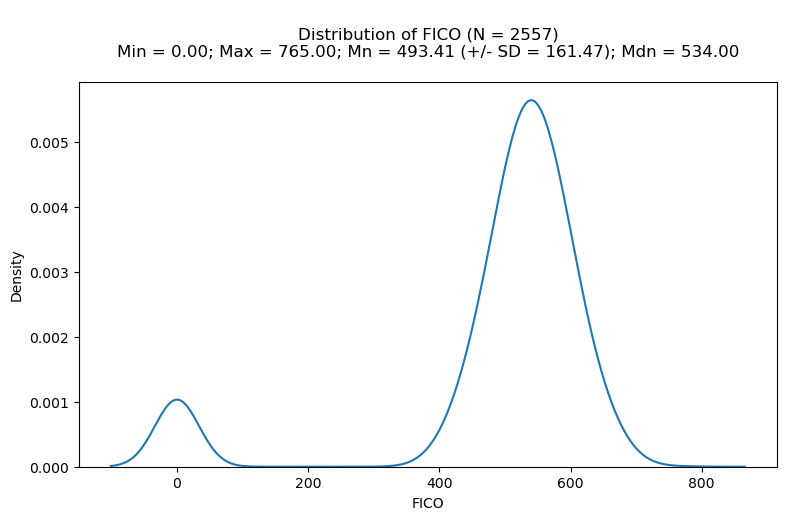

In [21]:
list_tmp = list(df_tmp['fico__app'])
int_n = len(list_tmp)
flt_min = np.min(list_tmp)
flt_max = np.max(list_tmp)
flt_mn = np.mean(list_tmp)
flt_sd = np.std(list_tmp)
flt_mdn = np.median(list_tmp)
str_title = f"""
Distribution of FICO (N = {int_n})
Min = {flt_min:0.2f}; Max = {flt_max:0.2f}; Mn = {flt_mn:0.2f} (+/- SD = {flt_sd:0.2f}); Mdn = {flt_mdn:0.2f}
"""
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('FICO')
sns.kdeplot(list_tmp, ax=ax)
plt.show()

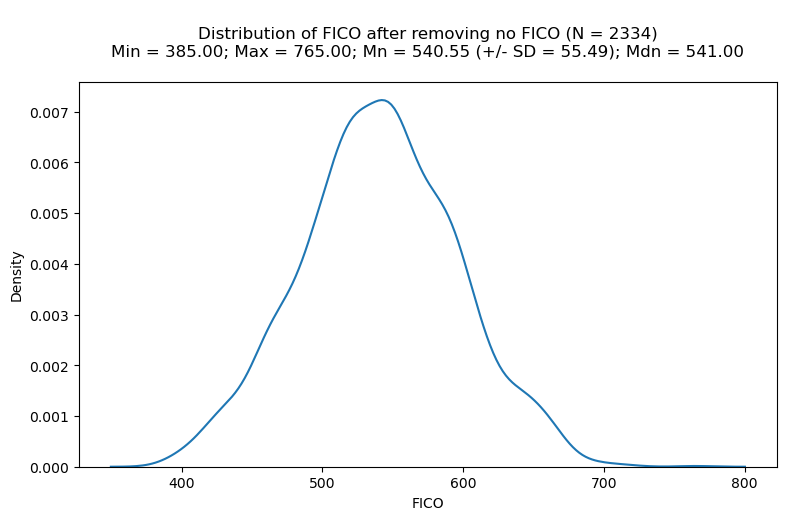

In [22]:
# rm 0s
list_tmp = list(df_tmp['fico__app'])
list_tmp = [flt_fico for flt_fico in list_tmp if flt_fico > 0]
int_n = len(list_tmp)
flt_min = np.min(list_tmp)
flt_max = np.max(list_tmp)
flt_mn = np.mean(list_tmp)
flt_sd = np.std(list_tmp)
flt_mdn = np.median(list_tmp)
str_title = f"""
Distribution of FICO after removing no FICO (N = {int_n})
Min = {flt_min:0.2f}; Max = {flt_max:0.2f}; Mn = {flt_mn:0.2f} (+/- SD = {flt_sd:0.2f}); Mdn = {flt_mdn:0.2f}
"""
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('FICO')
sns.kdeplot(list_tmp, ax=ax)
plt.show()

### Plot mean predictions by FICO quantile

In [23]:
int_n_quantiles_tmp = int_n_quantiles
while True:
    try:
        df_tmp['quantile'] = pd.qcut(
            df_tmp['fico__app'], 
            q=int_n_quantiles_tmp, 
            labels=list(range(1, int_n_quantiles_tmp+1)),
            duplicates='drop',
        )
        break
    except ValueError:
        int_n_quantiles_tmp -= 1

# group
df_tmp['count'] = 1
df_tmp['min'] = df_tmp['fico__app']
df_tmp['max'] = df_tmp['fico__app']
df_grouped_tmp = df_tmp.groupby('quantile', as_index=False).agg({
    'count': 'sum',
    'min': 'min',
    'max': 'max',
    'fico__app': 'mean',
    'pd': 'mean',
    'lgd': 'mean',
    'ecnl': 'mean',
    'prop_loss': 'mean',
})
# create better quantile label
df_grouped_tmp['quantile_label'] = df_grouped_tmp.apply(
    lambda x: f'{x["min"]} - {x["max"]}',
    axis=1,
)
# show
df_grouped_tmp

,quantile,count,min,max,fico__app,pd,lgd,ecnl,prop_loss,quantile_label
0,1,256,0.0,419.0,52.607422,0.285112,0.670660,0.192381,0.205214,0.0 - 419.0
1,2,257,421.0,474.0,453.752918,0.292216,0.663036,0.195069,0.251402,421.0 - 474.0
2,3,258,475.0,501.0,489.503876,0.302554,0.667424,0.202861,0.211164,475.0 - 501.0
3,4,253,501.5,518.0,510.531621,0.306660,0.667538,0.205374,0.192982,501.5 - 518.0
4,5,261,518.5,534.0,526.000000,0.286473,0.663992,0.191683,0.237942,518.5 - 534.0
5,6,252,534.5,548.0,541.829365,0.292397,0.662502,0.194962,0.163672,534.5 - 548.0
6,7,253,548.5,564.0,555.871542,0.291860,0.664117,0.195500,0.210626,548.5 - 564.0
7,8,261,564.5,584.0,574.275862,0.289242,0.664382,0.193132,0.179203,564.5 - 584.0
8,9,254,584.5,608.0,595.301181,0.276464,0.662386,0.184274,0.172738,584.5 - 608.0
9,10,252,609.0,765.0,637.083333,0.270062,0.663112,0.180131,0.160713,609.0 - 765.0


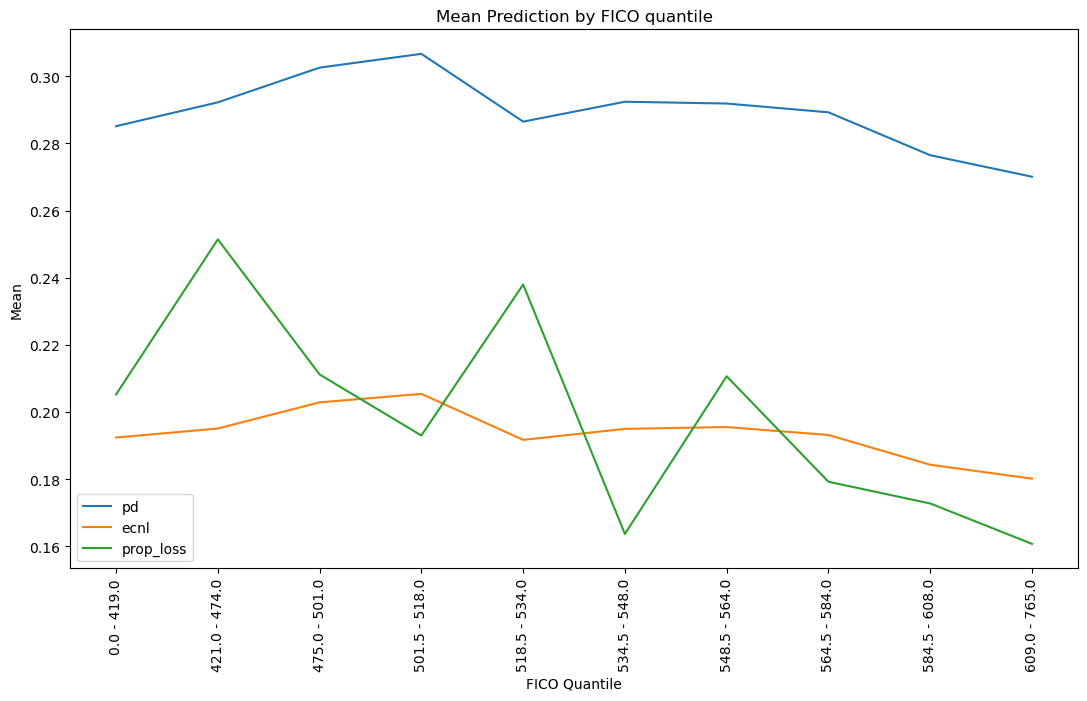

In [24]:
# line plots
list_cols = [
    'pd',
    #'lgd',
    'ecnl',
    'prop_loss',
]
# plot
fig, ax = plt.subplots(figsize=(13,7))
ax.set_title('Mean Prediction by FICO quantile')
ax.set_xlabel('FICO Quantile')
ax.set_ylabel('Mean')
for col in list_cols:
    ax.plot(df_grouped_tmp['quantile_label'].astype(str), df_grouped_tmp[col], label=col)
plt.legend(loc='lower left')
ax.set_xticklabels(df_grouped_tmp['quantile_label'].astype(str), rotation=90)
plt.show()

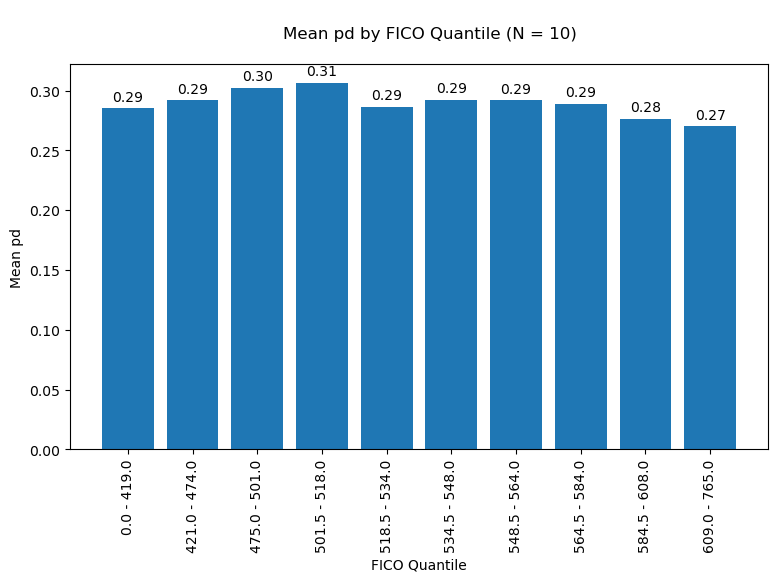

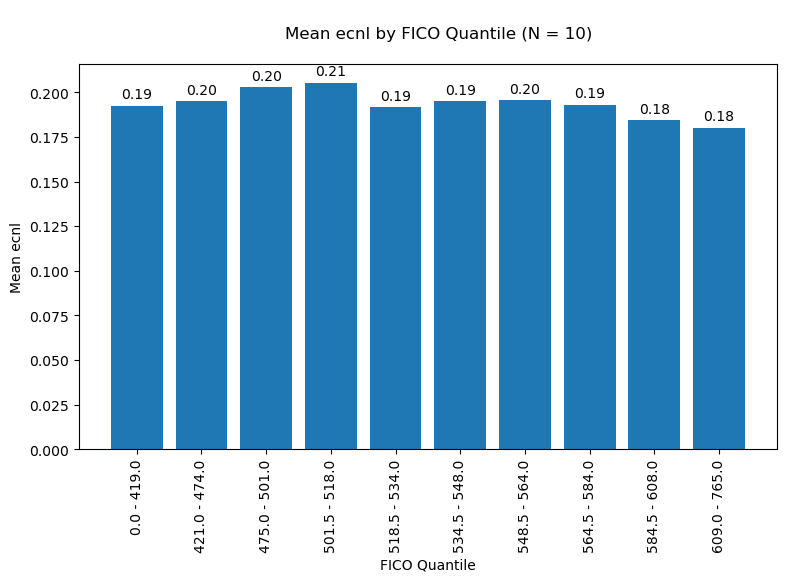

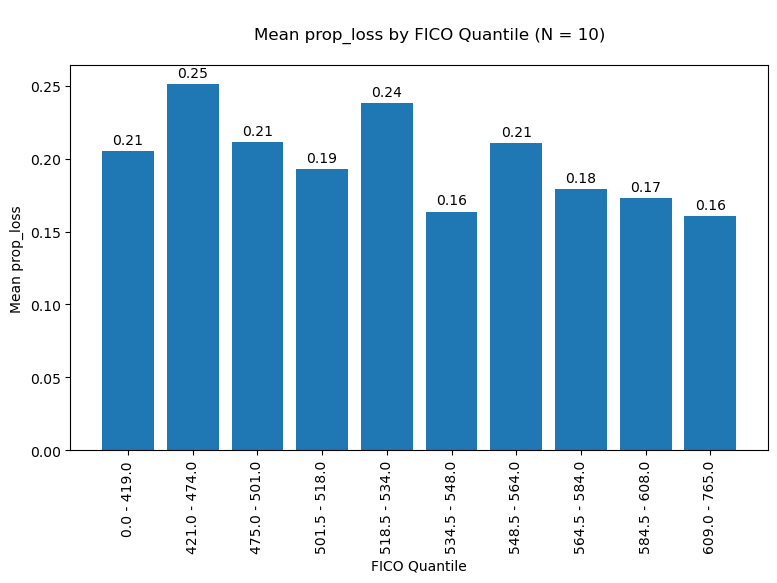

In [25]:
# bar plots
int_n = df_grouped_tmp.shape[0]
for col in list_cols:
    str_title = f"""
    Mean {col} by FICO Quantile (N = {int_n})
    """
    # ax
    fig, ax = plt.subplots(figsize=(9,5))
    # labels
    ax.set_title(str_title)
    ax.set_xlabel('FICO Quantile')
    ax.set_ylabel(f'Mean {col}')
    # plot
    bars = ax.bar(df_grouped_tmp['quantile_label'].astype(str), df_grouped_tmp[col])
    # bar labels
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:0.2f}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha='center',
            va='bottom',
        )
    # labels
    ax.set_xticklabels(df_grouped_tmp['quantile_label'].astype(str), rotation=90)
    # show
    plt.show()

### Identity

In [26]:
df_grouped_tmp.sort_values(by='ecnl', ascending=True, inplace=True)
df_grouped_tmp

,quantile,count,min,max,fico__app,pd,lgd,ecnl,prop_loss,quantile_label
9,10,252,609.0,765.0,637.083333,0.270062,0.663112,0.180131,0.160713,609.0 - 765.0
8,9,254,584.5,608.0,595.301181,0.276464,0.662386,0.184274,0.172738,584.5 - 608.0
4,5,261,518.5,534.0,526.000000,0.286473,0.663992,0.191683,0.237942,518.5 - 534.0
0,1,256,0.0,419.0,52.607422,0.285112,0.670660,0.192381,0.205214,0.0 - 419.0
7,8,261,564.5,584.0,574.275862,0.289242,0.664382,0.193132,0.179203,564.5 - 584.0
5,6,252,534.5,548.0,541.829365,0.292397,0.662502,0.194962,0.163672,534.5 - 548.0
1,2,257,421.0,474.0,453.752918,0.292216,0.663036,0.195069,0.251402,421.0 - 474.0
6,7,253,548.5,564.0,555.871542,0.291860,0.664117,0.195500,0.210626,548.5 - 564.0
2,3,258,475.0,501.0,489.503876,0.302554,0.667424,0.202861,0.211164,475.0 - 501.0
3,4,253,501.5,518.0,510.531621,0.306660,0.667538,0.205374,0.192982,501.5 - 518.0


### FICO Analysis - BK 7

In [27]:
df_tmp = df_grouped.copy()
df_tmp = df_tmp[df_tmp['intopenbktype__app'] == '7.0'].copy()
# get prop na
flt_isnull = df_tmp['fico__app'].isnull().mean()
print(f'Proportion with missing FICO: {flt_isnull:0.2f}')

# fill missing FICO with 0
df_tmp['fico__app'] = df_tmp['fico__app'].fillna(0)

# get prop na
flt_isnull = df_tmp['fico__app'].isnull().mean()
print(f'Proportion with missing FICO after imputing: {flt_isnull:0.2f}')

Proportion with missing FICO: 0.05
Proportion with missing FICO after imputing: 0.00


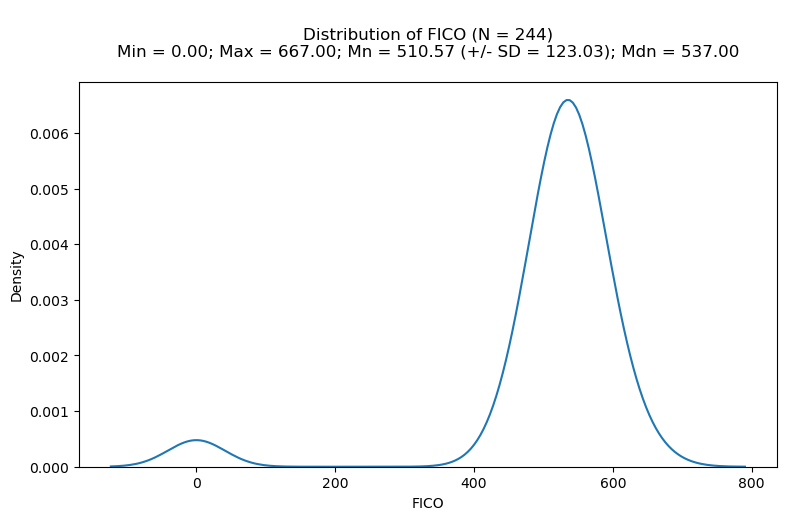

In [28]:
list_tmp = list(df_tmp['fico__app'])
int_n = len(list_tmp)
flt_min = np.min(list_tmp)
flt_max = np.max(list_tmp)
flt_mn = np.mean(list_tmp)
flt_sd = np.std(list_tmp)
flt_mdn = np.median(list_tmp)
str_title = f"""
Distribution of FICO (N = {int_n})
Min = {flt_min:0.2f}; Max = {flt_max:0.2f}; Mn = {flt_mn:0.2f} (+/- SD = {flt_sd:0.2f}); Mdn = {flt_mdn:0.2f}
"""
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('FICO')
sns.kdeplot(list_tmp, ax=ax)
plt.show()

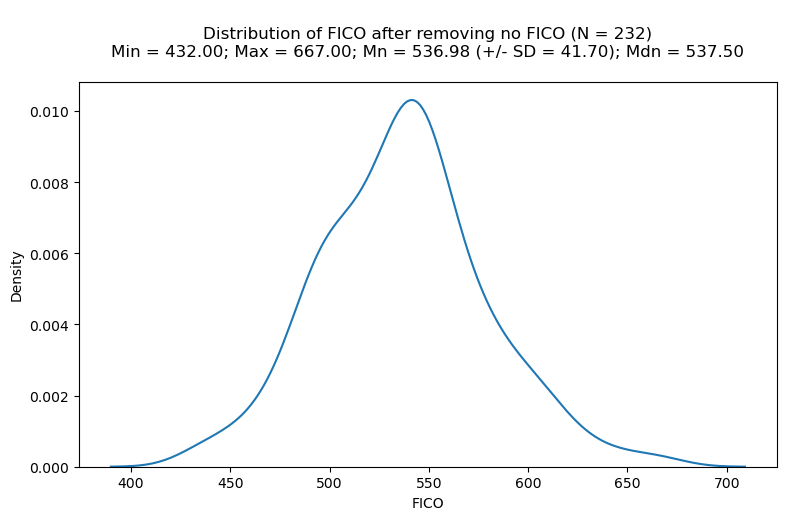

In [29]:
# rm 0s
list_tmp = list(df_tmp['fico__app'])
list_tmp = [flt_fico for flt_fico in list_tmp if flt_fico > 0]
int_n = len(list_tmp)
flt_min = np.min(list_tmp)
flt_max = np.max(list_tmp)
flt_mn = np.mean(list_tmp)
flt_sd = np.std(list_tmp)
flt_mdn = np.median(list_tmp)
str_title = f"""
Distribution of FICO after removing no FICO (N = {int_n})
Min = {flt_min:0.2f}; Max = {flt_max:0.2f}; Mn = {flt_mn:0.2f} (+/- SD = {flt_sd:0.2f}); Mdn = {flt_mdn:0.2f}
"""
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('FICO')
sns.kdeplot(list_tmp, ax=ax)
plt.show()

### Mean predictions by FICO quantile

In [30]:
int_n_quantiles_tmp = int_n_quantiles
while True:
    try:
        df_tmp['quantile'] = pd.qcut(
            df_tmp['fico__app'], 
            q=int_n_quantiles_tmp, 
            labels=list(range(1, int_n_quantiles_tmp+1)),
            duplicates='drop',
        )
        break
    except ValueError:
        int_n_quantiles_tmp -= 1

# group
df_tmp['count'] = 1
df_tmp['min'] = df_tmp['fico__app']
df_tmp['max'] = df_tmp['fico__app']
df_grouped_tmp = df_tmp.groupby('quantile', as_index=False).agg({
    'count': 'sum',
    'min': 'min',
    'max': 'max',
    'fico__app': 'mean',
    'pd': 'mean',
    'lgd': 'mean',
    'ecnl': 'mean',
    'prop_loss': 'mean',
})
# create better quantile label
df_grouped_tmp['quantile_label'] = df_grouped_tmp.apply(
    lambda x: f'{x["min"]} - {x["max"]}',
    axis=1,
)
# show
df_grouped_tmp

,quantile,count,min,max,fico__app,pd,lgd,ecnl,prop_loss,quantile_label
0,1,25,0.0,471.0,236.640000,0.314397,0.667191,0.212262,0.229276,0.0 - 471.0
1,2,24,473.0,495.0,487.229167,0.295302,0.679809,0.202837,0.224513,473.0 - 495.0
2,3,26,496.0,511.5,502.576923,0.261528,0.663917,0.173020,0.199985,496.0 - 511.5
3,4,23,513.0,524.0,518.065217,0.215560,0.669635,0.144664,0.141766,513.0 - 524.0
4,5,30,525.0,537.0,532.133333,0.207778,0.655227,0.137856,0.177711,525.0 - 537.0
5,6,19,538.0,544.0,541.421053,0.280279,0.663234,0.187199,0.237231,538.0 - 544.0
6,7,25,545.0,552.0,547.780000,0.254623,0.656034,0.168021,0.133630,545.0 - 552.0
7,8,23,553.0,566.0,558.652174,0.213303,0.666950,0.145284,0.231384,553.0 - 566.0
8,9,24,567.0,590.0,576.770833,0.219653,0.669645,0.148052,0.111560,567.0 - 590.0
9,10,25,591.0,667.0,614.020000,0.214319,0.658604,0.143991,0.178465,591.0 - 667.0


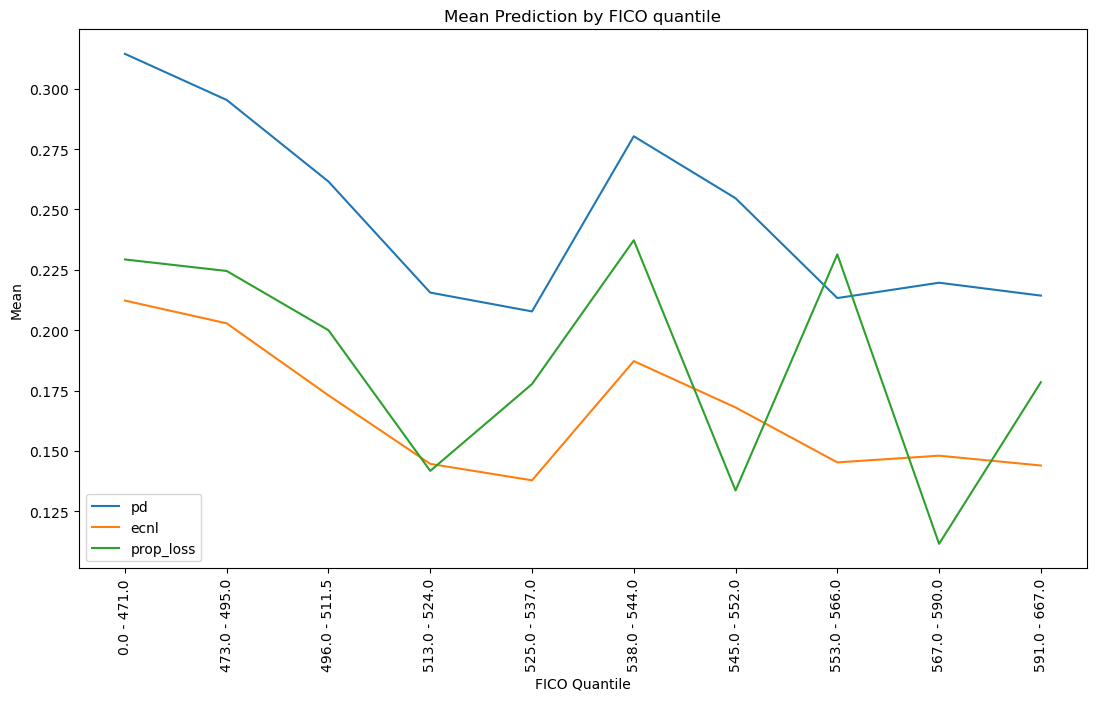

In [31]:
# line plots
list_cols = [
    'pd',
    #'lgd',
    'ecnl',
    'prop_loss',
]
# plot
fig, ax = plt.subplots(figsize=(13,7))
ax.set_title('Mean Prediction by FICO quantile')
ax.set_xlabel('FICO Quantile')
ax.set_ylabel('Mean')
for col in list_cols:
    ax.plot(df_grouped_tmp['quantile_label'].astype(str), df_grouped_tmp[col], label=col)
plt.legend(loc='lower left')
ax.set_xticklabels(df_grouped_tmp['quantile_label'].astype(str), rotation=90)
plt.show()

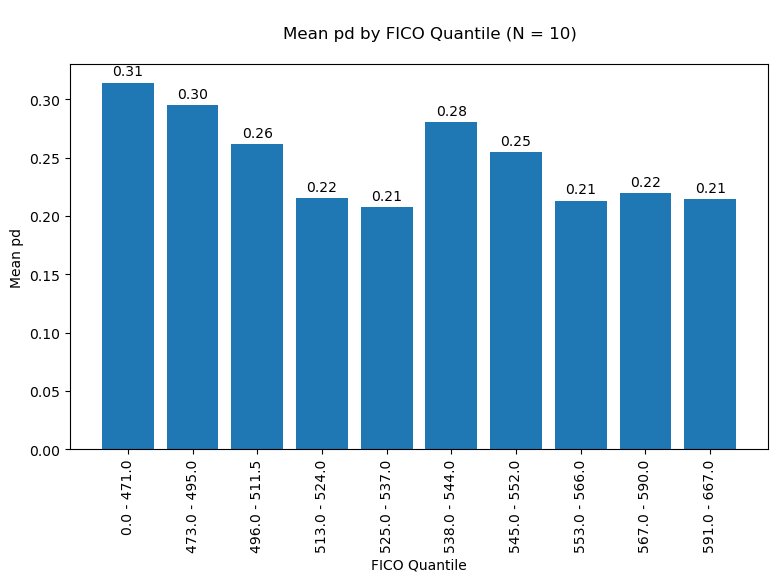

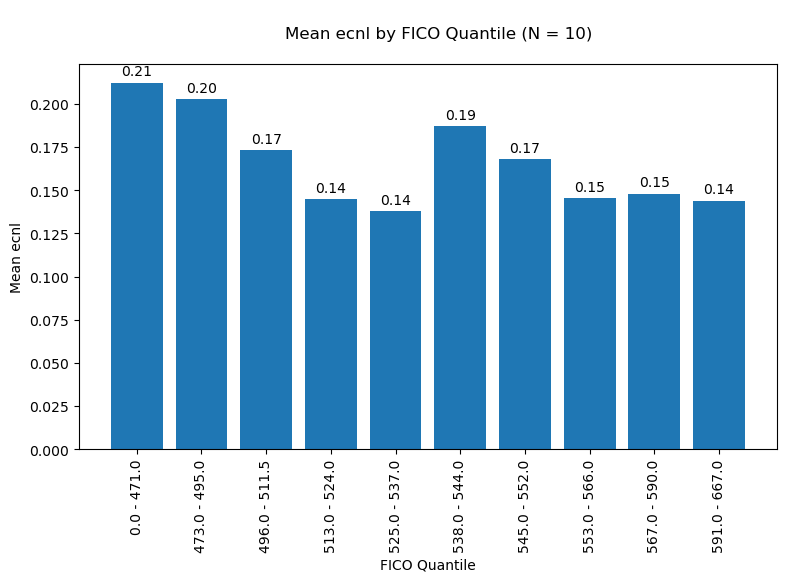

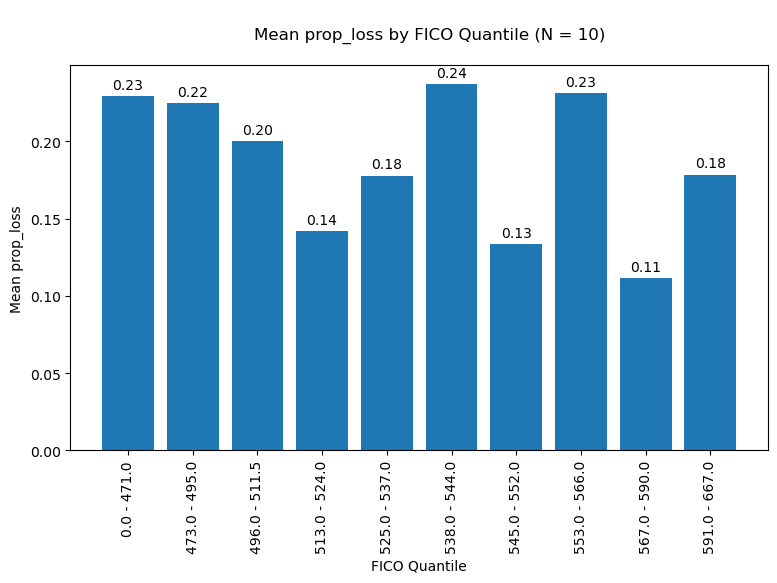

In [32]:
# bar plots
int_n = df_grouped_tmp.shape[0]
for col in list_cols:
    str_title = f"""
    Mean {col} by FICO Quantile (N = {int_n})
    """
    # ax
    fig, ax = plt.subplots(figsize=(9,5))
    # labels
    ax.set_title(str_title)
    ax.set_xlabel('FICO Quantile')
    ax.set_ylabel(f'Mean {col}')
    # plot
    bars = ax.bar(df_grouped_tmp['quantile_label'].astype(str), df_grouped_tmp[col])
    # bar labels
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:0.2f}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha='center',
            va='bottom',
        )
    # labels
    ax.set_xticklabels(df_grouped_tmp['quantile_label'].astype(str), rotation=90)
    # show
    plt.show()

### FICO Analysis - BK 13

In [33]:
df_tmp = df_grouped.copy()
df_tmp = df_tmp[df_tmp['intopenbktype__app'] == '13.0'].copy()
# get prop na
flt_isnull = df_tmp['fico__app'].isnull().mean()
print(f'Proportion with missing FICO: {flt_isnull:0.2f}')

# fill missing FICO with 0
df_tmp['fico__app'] = df_tmp['fico__app'].fillna(0)

# get prop na
flt_isnull = df_tmp['fico__app'].isnull().mean()
print(f'Proportion with missing FICO after imputing: {flt_isnull:0.2f}')

Proportion with missing FICO: 0.06
Proportion with missing FICO after imputing: 0.00


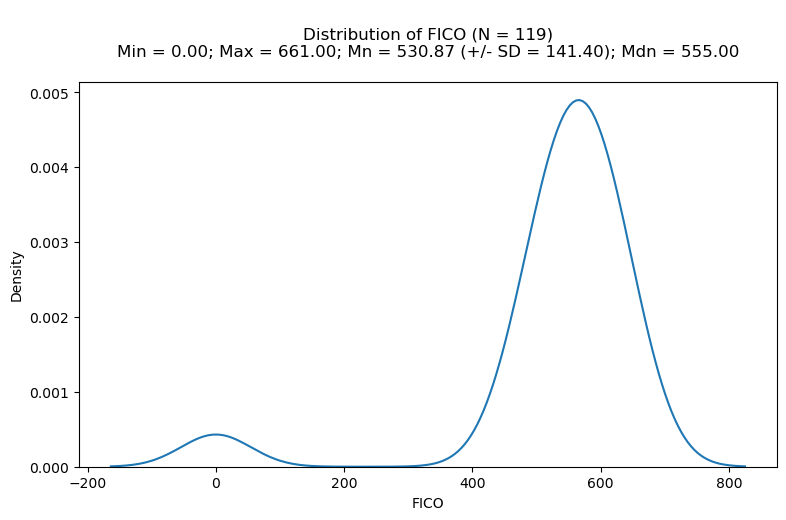

In [34]:
list_tmp = list(df_tmp['fico__app'])
int_n = len(list_tmp)
flt_min = np.min(list_tmp)
flt_max = np.max(list_tmp)
flt_mn = np.mean(list_tmp)
flt_sd = np.std(list_tmp)
flt_mdn = np.median(list_tmp)
str_title = f"""
Distribution of FICO (N = {int_n})
Min = {flt_min:0.2f}; Max = {flt_max:0.2f}; Mn = {flt_mn:0.2f} (+/- SD = {flt_sd:0.2f}); Mdn = {flt_mdn:0.2f}
"""
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('FICO')
sns.kdeplot(list_tmp, ax=ax)
plt.show()

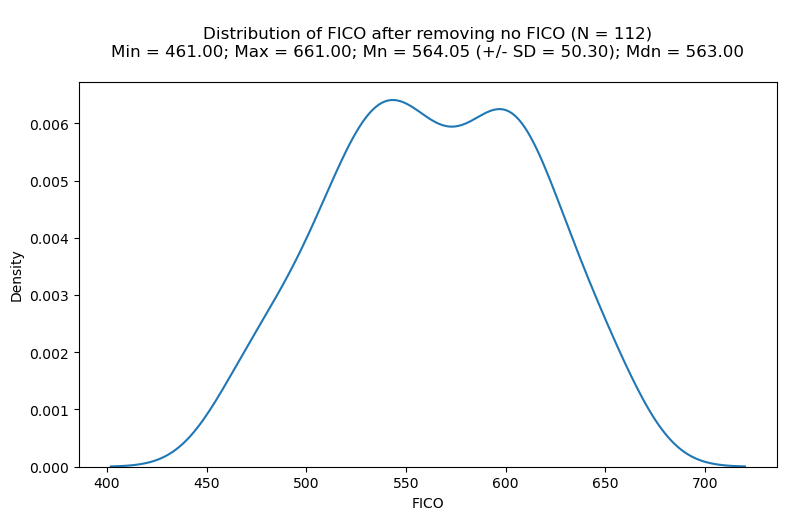

In [35]:
# rm 0s
list_tmp = list(df_tmp['fico__app'])
list_tmp = [flt_fico for flt_fico in list_tmp if flt_fico > 0]
int_n = len(list_tmp)
flt_min = np.min(list_tmp)
flt_max = np.max(list_tmp)
flt_mn = np.mean(list_tmp)
flt_sd = np.std(list_tmp)
flt_mdn = np.median(list_tmp)
str_title = f"""
Distribution of FICO after removing no FICO (N = {int_n})
Min = {flt_min:0.2f}; Max = {flt_max:0.2f}; Mn = {flt_mn:0.2f} (+/- SD = {flt_sd:0.2f}); Mdn = {flt_mdn:0.2f}
"""
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('FICO')
sns.kdeplot(list_tmp, ax=ax)
plt.show()

### Mean predictions by FICO quantile

In [36]:
int_n_quantiles_tmp = int_n_quantiles
while True:
    try:
        df_tmp['quantile'] = pd.qcut(
            df_tmp['fico__app'], 
            q=int_n_quantiles_tmp, 
            labels=list(range(1, int_n_quantiles_tmp+1)),
            duplicates='drop',
        )
        break
    except ValueError:
        int_n_quantiles_tmp -= 1

# group
df_tmp['count'] = 1
df_tmp['min'] = df_tmp['fico__app']
df_tmp['max'] = df_tmp['fico__app']
df_grouped_tmp = df_tmp.groupby('quantile', as_index=False).agg({
    'count': 'sum',
    'min': 'min',
    'max': 'max',
    'fico__app': 'mean',
    'pd': 'mean',
    'lgd': 'mean',
    'ecnl': 'mean',
    'prop_loss': 'mean',
})
# create better quantile label
df_grouped_tmp['quantile_label'] = df_grouped_tmp.apply(
    lambda x: f'{x["min"]} - {x["max"]}',
    axis=1,
)
# show
df_grouped_tmp

,quantile,count,min,max,fico__app,pd,lgd,ecnl,prop_loss,quantile_label
0,1,13,0.0,475.0,216.115385,0.277380,0.683733,0.190120,0.045513,0.0 - 475.0
1,2,11,483.0,507.0,495.454545,0.254495,0.696900,0.179684,0.082187,483.0 - 507.0
2,3,13,510.0,528.0,520.346154,0.206484,0.722519,0.150502,0.045835,510.0 - 528.0
3,4,11,529.0,543.0,535.727273,0.148129,0.682517,0.100698,0.066523,529.0 - 543.0
4,5,12,544.0,555.0,550.333333,0.177203,0.680210,0.120977,0.001264,544.0 - 555.0
5,6,11,555.5,574.5,567.000000,0.169845,0.686354,0.118182,0.056967,555.5 - 574.5
6,7,12,575.5,596.0,587.625000,0.137630,0.680541,0.094091,0.002687,575.5 - 596.0
7,8,12,597.0,606.0,601.583333,0.114536,0.679791,0.082014,0.011715,597.0 - 606.0
8,9,12,607.0,625.0,617.458333,0.115534,0.678050,0.080629,0.000000,607.0 - 625.0
9,10,12,629.0,661.0,644.625000,0.104361,0.654441,0.069097,0.000000,629.0 - 661.0


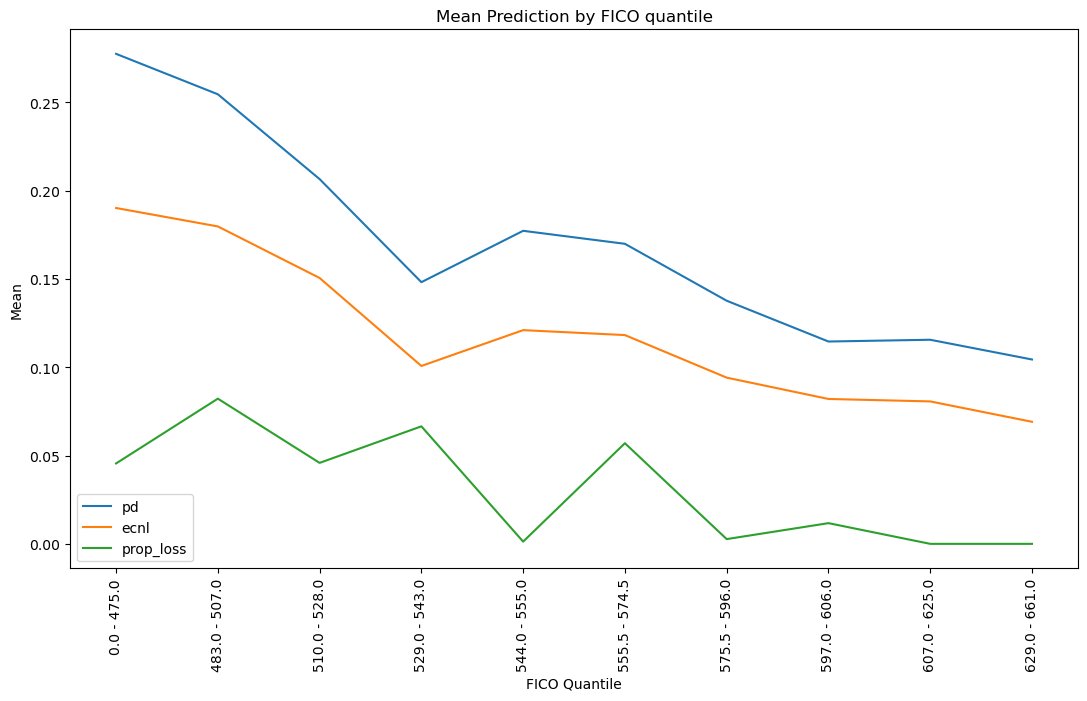

In [37]:
# line plots
list_cols = [
    'pd',
    #'lgd',
    'ecnl',
    'prop_loss',
]
# plot
fig, ax = plt.subplots(figsize=(13,7))
ax.set_title('Mean Prediction by FICO quantile')
ax.set_xlabel('FICO Quantile')
ax.set_ylabel('Mean')
for col in list_cols:
    ax.plot(df_grouped_tmp['quantile_label'].astype(str), df_grouped_tmp[col], label=col)
plt.legend(loc='lower left')
ax.set_xticklabels(df_grouped_tmp['quantile_label'].astype(str), rotation=90)
plt.show()

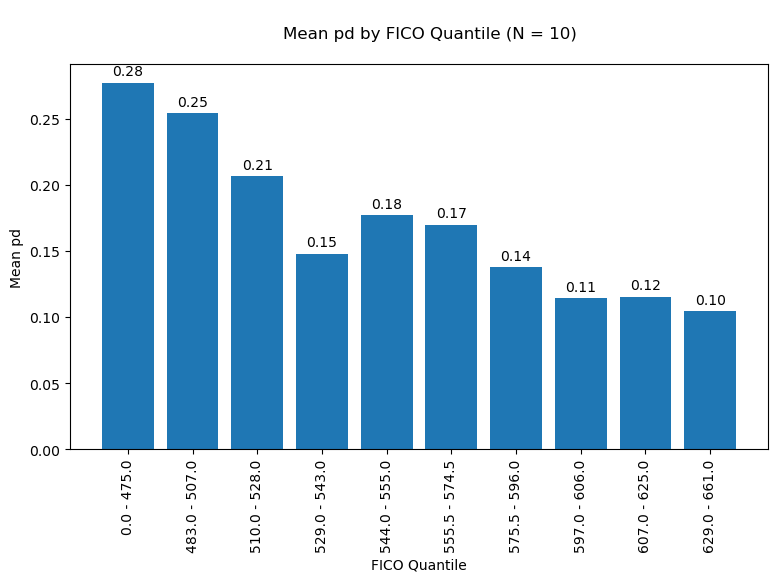

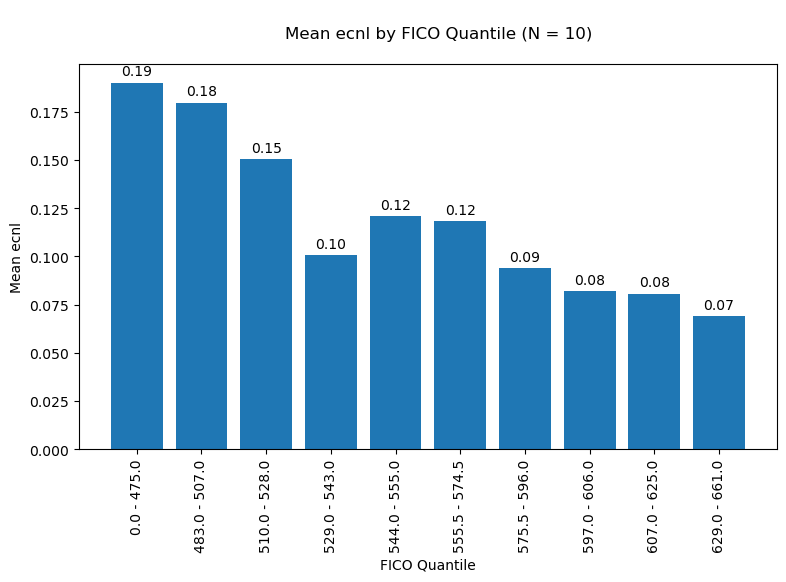

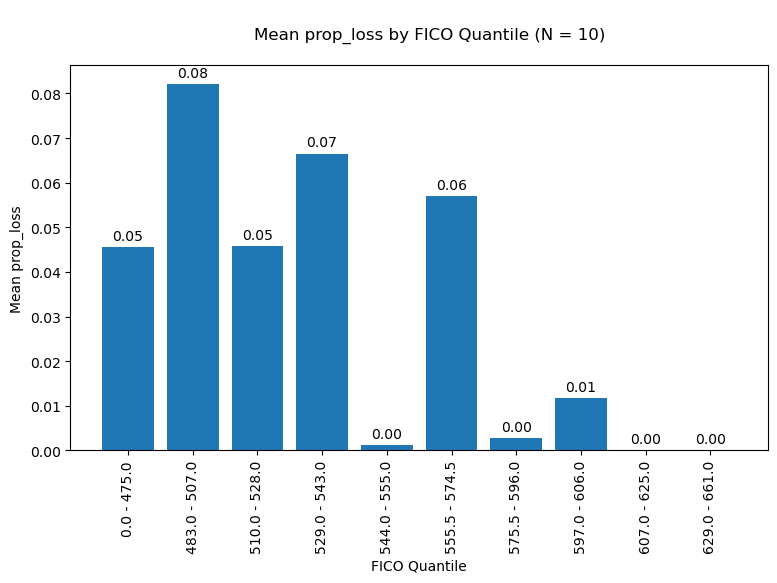

In [38]:
# bar plots
int_n = df_grouped_tmp.shape[0]
for col in list_cols:
    str_title = f"""
    Mean {col} by FICO Quantile (N = {int_n})
    """
    # ax
    fig, ax = plt.subplots(figsize=(9,5))
    # labels
    ax.set_title(str_title)
    ax.set_xlabel('FICO Quantile')
    ax.set_ylabel(f'Mean {col}')
    # plot
    bars = ax.bar(df_grouped_tmp['quantile_label'].astype(str), df_grouped_tmp[col])
    # bar labels
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:0.2f}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha='center',
            va='bottom',
        )
    # labels
    ax.set_xticklabels(df_grouped_tmp['quantile_label'].astype(str), rotation=90)
    # show
    plt.show()

### FICO Analysis - No BK

In [39]:
df_tmp = df_grouped.copy()
df_tmp = df_tmp[df_tmp['intopenbktype__app'] == 'nan'].copy()
# get prop na
flt_isnull = df_tmp['fico__app'].isnull().mean()
print(f'Proportion with missing FICO: {flt_isnull:0.2f}')

# fill missing FICO with 0
df_tmp['fico__app'] = df_tmp['fico__app'].fillna(0)

# get prop na
flt_isnull = df_tmp['fico__app'].isnull().mean()
print(f'Proportion with missing FICO after imputing: {flt_isnull:0.2f}')

Proportion with missing FICO: 0.09
Proportion with missing FICO after imputing: 0.00


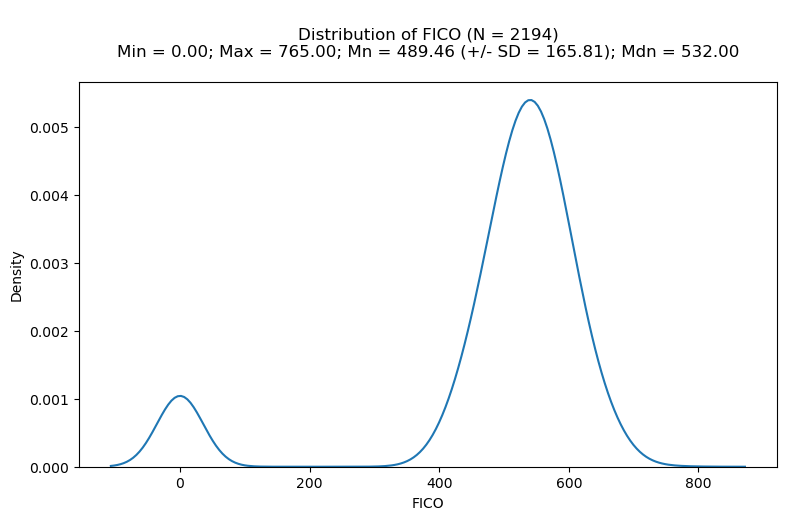

In [40]:
list_tmp = list(df_tmp['fico__app'])
int_n = len(list_tmp)
flt_min = np.min(list_tmp)
flt_max = np.max(list_tmp)
flt_mn = np.mean(list_tmp)
flt_sd = np.std(list_tmp)
flt_mdn = np.median(list_tmp)
str_title = f"""
Distribution of FICO (N = {int_n})
Min = {flt_min:0.2f}; Max = {flt_max:0.2f}; Mn = {flt_mn:0.2f} (+/- SD = {flt_sd:0.2f}); Mdn = {flt_mdn:0.2f}
"""
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('FICO')
sns.kdeplot(list_tmp, ax=ax)
plt.show()

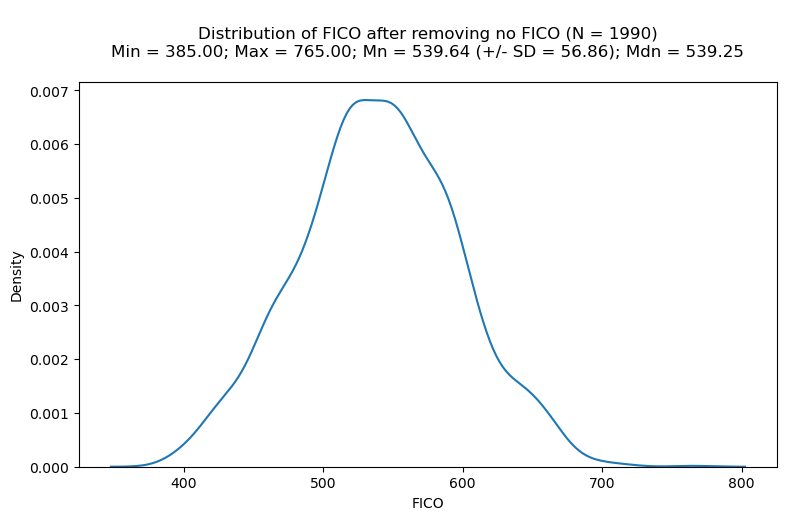

In [41]:
# rm 0s
list_tmp = list(df_tmp['fico__app'])
list_tmp = [flt_fico for flt_fico in list_tmp if flt_fico > 0]
int_n = len(list_tmp)
flt_min = np.min(list_tmp)
flt_max = np.max(list_tmp)
flt_mn = np.mean(list_tmp)
flt_sd = np.std(list_tmp)
flt_mdn = np.median(list_tmp)
str_title = f"""
Distribution of FICO after removing no FICO (N = {int_n})
Min = {flt_min:0.2f}; Max = {flt_max:0.2f}; Mn = {flt_mn:0.2f} (+/- SD = {flt_sd:0.2f}); Mdn = {flt_mdn:0.2f}
"""
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('FICO')
sns.kdeplot(list_tmp, ax=ax)
plt.show()

### Mean predictions by FICO quantile

In [42]:
int_n_quantiles_tmp = int_n_quantiles
while True:
    try:
        df_tmp['quantile'] = pd.qcut(
            df_tmp['fico__app'], 
            q=int_n_quantiles_tmp, 
            labels=list(range(1, int_n_quantiles_tmp+1)),
            duplicates='drop',
        )
        break
    except ValueError:
        int_n_quantiles_tmp -= 1

# group
df_tmp['count'] = 1
df_tmp['min'] = df_tmp['fico__app']
df_tmp['max'] = df_tmp['fico__app']
df_grouped_tmp = df_tmp.groupby('quantile', as_index=False).agg({
    'count': 'sum',
    'min': 'min',
    'max': 'max',
    'fico__app': 'mean',
    'pd': 'mean',
    'lgd': 'mean',
    'ecnl': 'mean',
    'prop_loss': 'mean',
})
# create better quantile label
df_grouped_tmp['quantile_label'] = df_grouped_tmp.apply(
    lambda x: f'{x["min"]} - {x["max"]}',
    axis=1,
)
# show
df_grouped_tmp

,quantile,count,min,max,fico__app,pd,lgd,ecnl,prop_loss,quantile_label
0,1,220,0.0,409.0,29.118182,0.290387,0.670423,0.195870,0.199597,0.0 - 409.0
1,2,220,410.0,470.0,447.379545,0.289563,0.663121,0.192918,0.261386,410.0 - 470.0
2,3,221,470.5,498.0,485.126697,0.300595,0.665043,0.201246,0.223802,470.5 - 498.0
3,4,226,498.5,517.0,508.568584,0.314433,0.665915,0.210124,0.194460,498.5 - 517.0
4,5,214,517.5,532.0,524.177570,0.307404,0.661135,0.205018,0.258718,517.5 - 532.0
5,6,220,532.5,548.0,540.790909,0.305667,0.663301,0.204254,0.180259,532.5 - 548.0
6,7,215,548.5,564.5,556.069767,0.305248,0.662357,0.203729,0.216122,548.5 - 564.5
7,8,223,565.0,584.0,574.340807,0.306806,0.663387,0.204692,0.201624,565.0 - 584.0
8,9,219,584.5,608.0,594.931507,0.293891,0.660437,0.195249,0.178149,584.5 - 608.0
9,10,216,609.0,765.0,638.127315,0.290422,0.663363,0.193663,0.180948,609.0 - 765.0


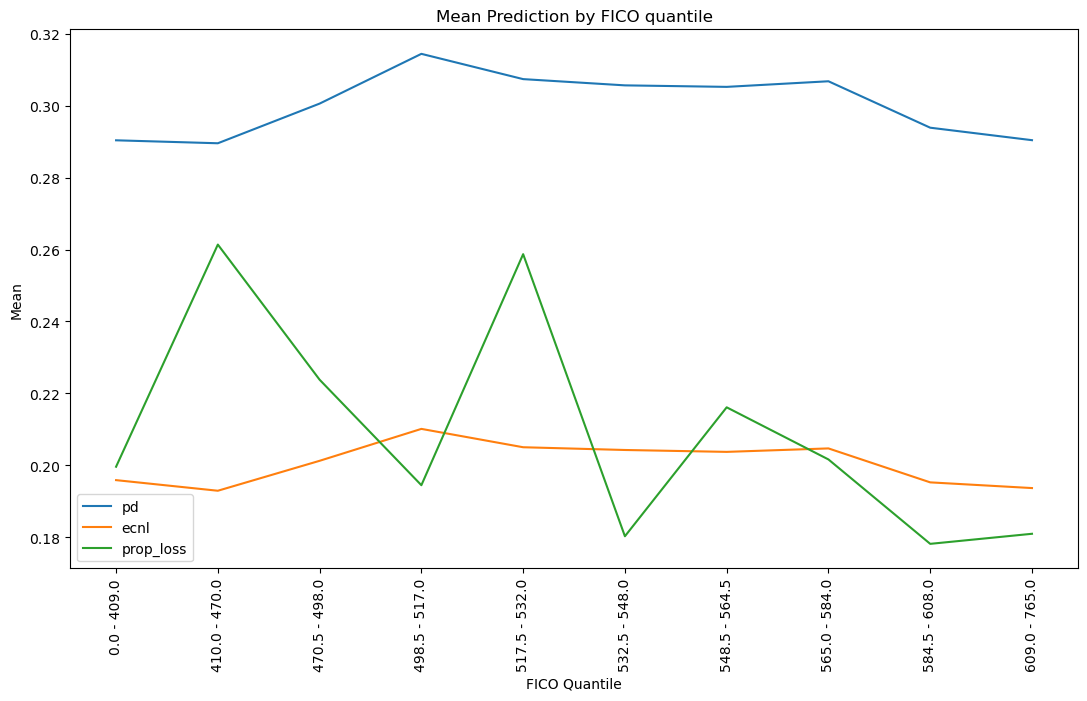

In [43]:
# line plots
list_cols = [
    'pd',
    #'lgd',
    'ecnl',
    'prop_loss',
]
# plot
fig, ax = plt.subplots(figsize=(13,7))
ax.set_title('Mean Prediction by FICO quantile')
ax.set_xlabel('FICO Quantile')
ax.set_ylabel('Mean')
for col in list_cols:
    ax.plot(df_grouped_tmp['quantile_label'].astype(str), df_grouped_tmp[col], label=col)
plt.legend(loc='lower left')
ax.set_xticklabels(df_grouped_tmp['quantile_label'].astype(str), rotation=90)
plt.show()

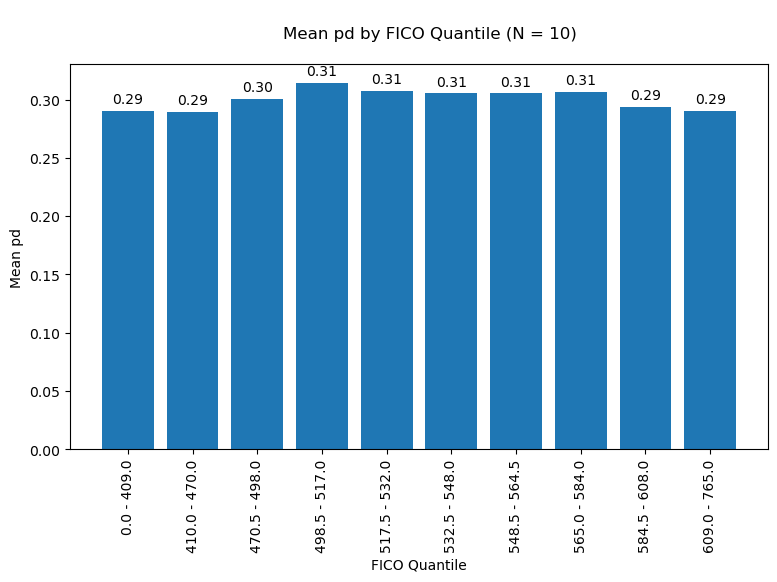

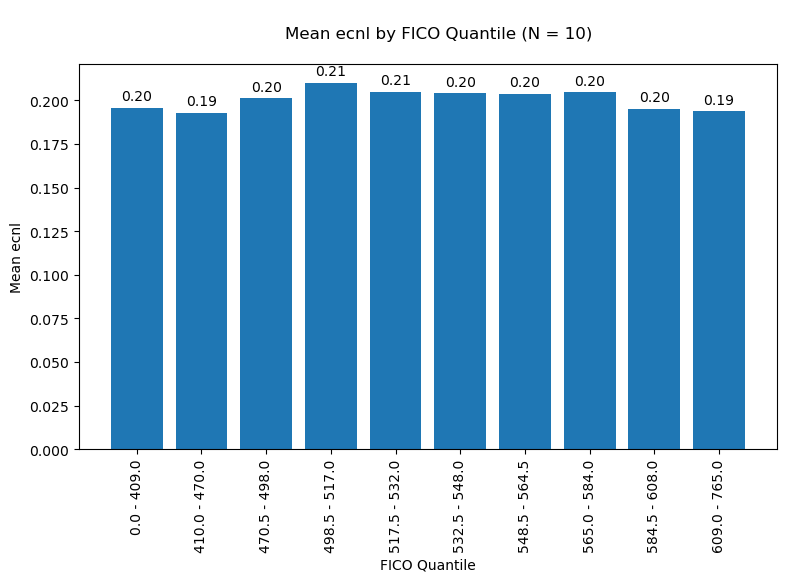

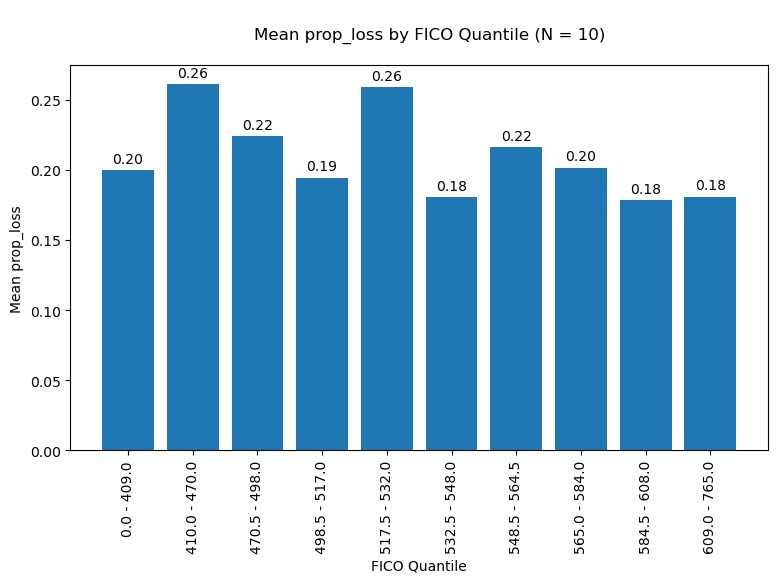

In [44]:
# bar plots
int_n = df_grouped_tmp.shape[0]
for col in list_cols:
    str_title = f"""
    Mean {col} by FICO Quantile (N = {int_n})
    """
    # ax
    fig, ax = plt.subplots(figsize=(9,5))
    # labels
    ax.set_title(str_title)
    ax.set_xlabel('FICO Quantile')
    ax.set_ylabel(f'Mean {col}')
    # plot
    bars = ax.bar(df_grouped_tmp['quantile_label'].astype(str), df_grouped_tmp[col])
    # bar labels
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:0.2f}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha='center',
            va='bottom',
        )
    # labels
    ax.set_xticklabels(df_grouped_tmp['quantile_label'].astype(str), rotation=90)
    # show
    plt.show()

### Group by month

In [45]:
df_grouped_tmp = df_grouped.groupby(by='app_month', as_index=False).agg({
    'prop_loss': 'mean',
    'ecnl': 'mean',
})
df_grouped_tmp

,app_month,prop_loss,ecnl
0,2022-01-01,0.184645,0.194225
1,2022-02-01,0.203052,0.193345


## Holdout data

In [46]:
df_tmp = df[df['data_set'] == 'holdout'].copy()
df_tmp

,bigAccountId,applicationdate__app,target,amtfinanced__app,bookvalue__app,intopenbktype__app,bitdebtor__app,fico__app,fltgrossmonthly__income_sum,bankruptcystatus__ln,...,prop_loss,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,pd,lgd
3228,5951341,2022-03-01 07:47:45.010,0,21000.0,16500.0,nan,1,562.0,2500.0,0.0,...,0.000000,2022,1.0,3,1,1.272727,3.0,2.049315,0.325673,0.657692
3227,5951341,2022-03-01 07:47:45.010,0,21000.0,16500.0,nan,0,562.0,2500.0,0.0,...,0.000000,2022,1.0,3,1,1.272727,3.0,2.049315,0.338807,0.647556
3229,5951349,2022-03-01 07:59:06.407,1,26000.0,24500.0,nan,1,471.0,5000.0,1.0,...,0.356342,2022,1.0,3,1,1.061224,2.0,0.186301,0.359412,0.724827
3230,5951363,2022-03-01 08:15:52.030,0,27500.0,22500.0,7.0,1,498.0,4500.0,-1.0,...,0.000000,2022,1.0,3,1,1.222222,5.0,8.816438,0.418312,0.692347
3231,5951374,2022-03-01 08:23:02.303,0,21500.0,20500.0,nan,1,501.0,4000.0,0.0,...,0.000000,2022,1.0,3,1,1.048780,5.0,8.621918,0.181674,0.675913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30915,6516344,2022-12-28 14:28:25.923,0,20500.0,16500.0,7.0,1,528.0,3500.0,-1.0,...,0.000000,2022,1.0,12,4,1.242424,5.0,13.534247,0.290228,0.648885
30916,6516517,2022-12-28 15:11:41.943,0,19500.0,13500.0,nan,1,562.0,5000.0,0.0,...,0.000000,2022,1.0,12,4,1.444444,9.0,7.684932,0.301258,0.607214
30918,6517682,2022-12-29 11:15:23.287,1,28000.0,20500.0,nan,1,502.0,5000.0,2.0,...,0.640403,2022,1.0,12,4,1.365854,5.0,14.906849,0.348762,0.709434
30917,6517682,2022-12-29 11:15:23.287,1,28000.0,20500.0,nan,0,497.0,2000.0,2.0,...,0.640403,2022,1.0,12,4,1.365854,5.0,14.906849,0.367784,0.673064


### Group

In [47]:
list_cols = [
    'bigAccountId',
    'bitdebtor__app',
]
df_tmp.sort_values(by=list_cols, ascending=[True, False], inplace=True)

# get app month
df_tmp['app_month'] = df[str_datecol].dt.to_period('M').dt.to_timestamp()

# group
df_grouped = df_tmp.groupby(by='bigAccountId', as_index=False).agg({
    'app_month': 'first',
    'prop_loss': 'first',
    'pd': 'mean',
    'lgd': 'mean',
})

# get ecnl
df_grouped['ecnl'] = df_grouped['pd'] * df_grouped['lgd']

# show
df_grouped

,bigAccountId,app_month,prop_loss,pd,lgd,ecnl
0,5951341,2022-03-01,0.000000,0.332240,0.652624,0.216828
1,5951349,2022-03-01,0.356342,0.359412,0.724827,0.260512
2,5951363,2022-03-01,0.000000,0.418312,0.692347,0.289617
3,5951374,2022-03-01,0.000000,0.181674,0.675913,0.122796
4,5951406,2022-03-01,0.927374,0.350989,0.710438,0.249356
...,...,...,...,...,...,...
22340,6516218,2022-12-01,0.512350,0.364562,0.652331,0.237815
22341,6516344,2022-12-01,0.000000,0.290228,0.648885,0.188325
22342,6516517,2022-12-01,0.000000,0.301258,0.607214,0.182928
22343,6517682,2022-12-01,0.640403,0.358273,0.691249,0.247656


### Group by month

In [48]:
df_grouped_tmp = df_grouped.groupby(by='app_month', as_index=False).agg({
    'prop_loss': 'mean',
    'ecnl': 'mean',
})
df_grouped_tmp

,app_month,prop_loss,ecnl
0,2022-03-01,0.187435,0.192977
1,2022-04-01,0.200045,0.192199
2,2022-05-01,0.206109,0.192336
3,2022-06-01,0.205687,0.190776
4,2022-07-01,0.171864,0.176593
5,2022-08-01,0.177883,0.178583
6,2022-09-01,0.179387,0.182426
7,2022-10-01,0.164806,0.169759
8,2022-11-01,0.158105,0.162029
9,2022-12-01,0.139864,0.165496


### Plot it

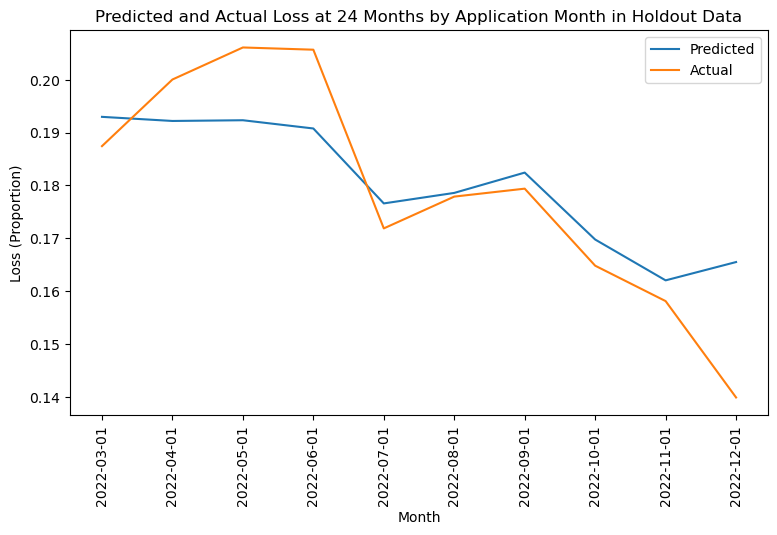

In [49]:
x = df_grouped_tmp['app_month'].astype(str)
y = df_grouped_tmp['prop_loss']
z = df_grouped_tmp['ecnl']

fig, ax = plt.subplots(figsize=(9,5))
str_title = 'Predicted and Actual Loss at 24 Months by Application Month in Holdout Data'
ax.set_title(str_title)
ax.set_xlabel('Month')
ax.set_ylabel('Loss (Proportion)')
ax.plot(x, z, label='Predicted')
ax.plot(x, y, label='Actual')
ax.tick_params(axis='x', rotation=90)

# legend
plt.legend()
# show
plt.show()